## GWAS annotation

In [ ]:
!wget https://storage.googleapis.com/adult-gtex/bulk-qtl/v10/single-tissue-cis-qtl/GTEx_Analysis_v10_eQTL.tar

--2026-02-12 14:53:14--  https://storage.googleapis.com/adult-gtex/bulk-qtl/v10/single-tissue-cis-qtl/GTEx_Analysis_v10_eQTL.tar
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.73.123, 142.251.34.219, 142.251.45.155, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.73.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2561047718 (2.4G) [application/x-tar]
Saving to: ‘GTEx_Analysis_v10_eQTL.tar’

GTEx_Analysis_v10_e 100%[===================>]   2.38G  15.9MB/s    in 2m 38s  

2026-02-12 14:55:53 (15.5 MB/s) - ‘GTEx_Analysis_v10_eQTL.tar’ saved [2561047718/2561047718]



In [ ]:
!tar -zxvf GTEx_Analysis_v10_eQTL.tar

GTEx_Analysis_v10_eQTL_updated/
GTEx_Analysis_v10_eQTL_updated/Prostate.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Stomach.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Skin_Not_Sun_Exposed_Suprapubic.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Spleen.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Minor_Salivary_Gland.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Heart_Left_Ventricle.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Pituitary.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Minor_Salivary_Gland.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Esophagus_Mucosa.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Brain_Cerebellar_Hemisphere.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Adipose_Subcutaneous.v10.eQTLs.signif_pairs.parquet
GTEx_Analysis_v10_eQTL_updated/Adrenal_Gland.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Nerve_Tibial.v10.eGenes.txt.gz
GTEx_Analysis_v10_eQTL_updated/Uterus.v10.eG

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load GWAS variant data
df_gwas = pd.read_csv("../../results/reproducibility/gwas_resources/match_GWAS.csv")

# Mapping between cell lines and GTEx tissues
cell_to_gtex = {
    'HepG2': 'Liver',
    'K562': 'Whole_Blood',
    'HEK293': 'Kidney_Cortex',
    'HEK293T': 'Kidney_Cortex',
}

# Function to load GTEx eQTL summary data
def load_eqtl_data(gtex_file):
    """
    Load GTEx eQTL data from a gzip-compressed tab-delimited file.
    """
    return pd.read_csv(gtex_file, sep="\t", compression="gzip")

# List to store processed results from all cell lines
eqtl_dfs = []

# Iterate through each cell line and its corresponding GTEx tissue
for cell_line, gtex_organ in cell_to_gtex.items():
    # Load the corresponding GTEx eQTL file
    gtex_file = f"GTEx_Analysis_v10_eQTL_updated/{gtex_organ}.v10.eGenes.txt.gz"
    eqtl_data = load_eqtl_data(gtex_file)

    # Rename rsID column for consistency with GWAS data
    eqtl_data.rename(columns={'rs_id_dbSNP155_GRCh38p13': 'rsid'}, inplace=True)

    # Filter GWAS variants for the current cell line
    df_cell = df_gwas[df_gwas['cell'] == cell_line]

    # Merge GWAS data with eQTL data by rsID
    df_merge = df_cell.merge(eqtl_data[['rsid', 'pval_nominal']], on='rsid', how='left')

    # Compute -log10(p) for eQTL p-values (missing values are set to 1 → log10(1) = 0)
    df_merge['log10_p'] = -np.log10(df_merge['pval_nominal'].fillna(1.0))

    # Mark significant eQTLs (p-value < 1e-5)
    threshold = 1e-5
    df_merge['is_significant_eqtl'] = df_merge['pval_nominal'] < threshold

    # Add cell line label
    df_merge['cell_line'] = cell_line

    # Append processed data to the list
    eqtl_dfs.append(df_merge)

# Combine all processed data into one DataFrame
all_data = pd.concat(eqtl_dfs, ignore_index=True)
output_eqtl_gwas = "../../results/reproducibility/gwas_resources/all_eqtl_gwas_data.csv"
# Save the merged dataset to a CSV file
all_data.to_csv(output_eqtl_gwas, index=False)


In [4]:
# ---------------------------------------------------------------------
# eQTL–GWAS integration plots: load data and prepare a smooth diverging palette
# ---------------------------------------------------------------------
# Input:
#   - ../../results/reproducibility/gwas_resources/all_eqtl_gwas_data.csv
#     Required columns (used downstream): is_significant_eqtl, alt_score, ref_score, log10_p, cell_line, ...
#
# Output:
#   - Objects in memory: data, sig_data (used by subsequent plotting cells)

library(ggplot2)
library(dplyr)
library(readr)
library(broom)
library(ggh4x)
library(RColorBrewer)
library(scales)   # helpers such as oob = squish

output_eqtl_gwas <- "../../results/reproducibility/gwas_resources/all_eqtl_gwas_data.csv"

# Build a custom diverging palette (smooth enough for continuous density shading)
# 1) Concatenate two Brewer palettes
pal <- c(
  brewer.pal(11, "PRGn")[3:6],          # purple -> green
  rev(brewer.pal(11, "RdYlBu")[2:5])    # orange/red -> yellow (drop extreme ends)
)

# 2) Interpolate within the range (100 steps for a smooth gradient)
my_pal <- colorRampPalette(pal)(100)
# If you want darker colors at higher values, keep the order; to reverse: rev(my_pal)

# Register Calibri (update path for your OS)
library(showtext)
font_add(family = "Calibri", regular = "/home/wangyubo/.Fonts/calibri.ttf")
showtext_auto()    # make ggplot2 use showtext

# Load CSV
data <- read_csv(output_eqtl_gwas)

# Keep significant eQTLs only and compute effect size (ALT - REF)
sig_data <- data %>%
  filter(is_significant_eqtl == TRUE) %>%
  mutate(effect_size = alt_score - ref_score)

# Count significant eQTLs (QC)
sig_count <- nrow(sig_data)

# Ensure effect_size exists (redundant-safe)
sig_data <- sig_data %>%
  mutate(effect_size = alt_score - ref_score)


Rows: 158272 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): rsid, rbp, cell, region, clin_sig, gene, chr, strand, gene_name, c...
dbl  (8): MAF, alt_score, ref_score, start_pos, end_pos, p_value, pval_nomin...
lgl  (1): is_significant_eqtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ scales::col_factor() masks readr::col_factor()
✖ purrr::discard()     masks scales::discard()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::lag()         masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal


Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”


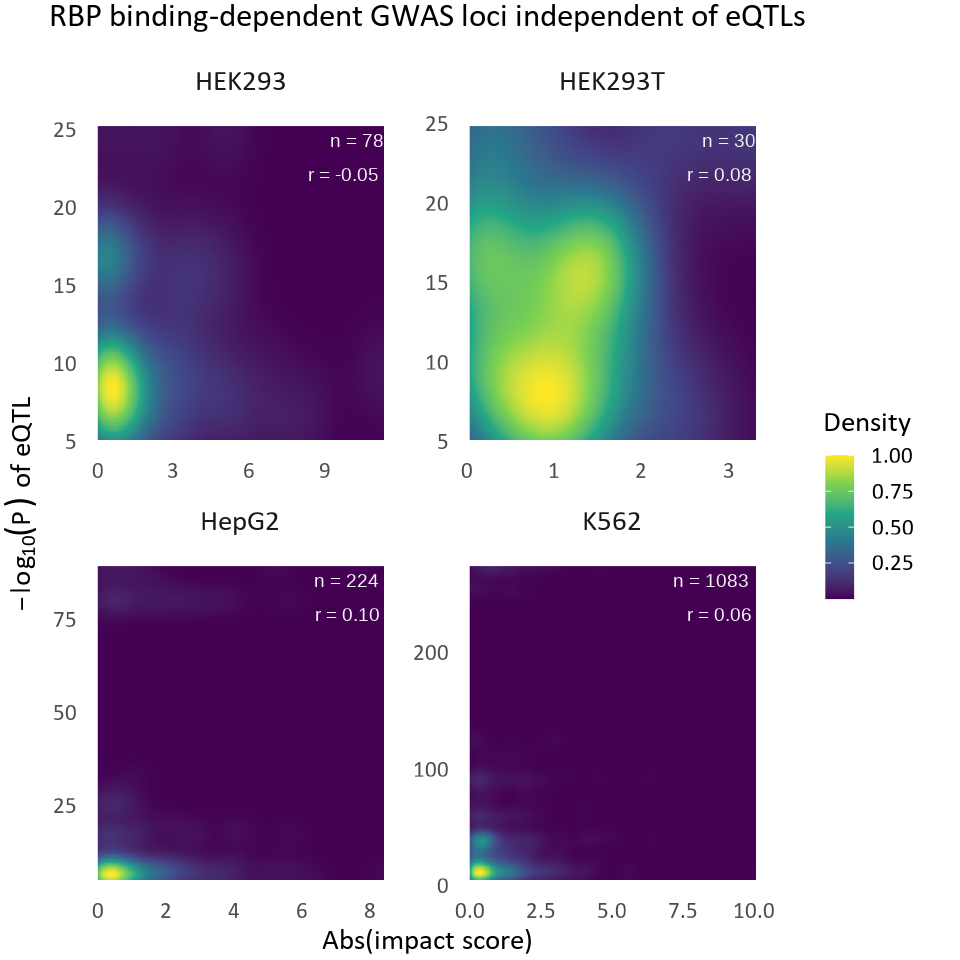

In [5]:
############################################################
# effect_size_vs_log10p_by_cellline2 — faceted density + per-cell correlation
############################################################
# Purpose:
#   Same as the overall plot, but faceted by cell_line and annotated with
#   per-facet n and r.
#
# Input (in memory):
#   - sig_data with columns: alt_score, ref_score, log10_p, cell_line
#
# Output:
#   - effect_size_vs_log10p_by_cellline_HEK293_HepG2.pdf

# Ensure effect_size and abs_effect_size exist
sig_data <- sig_data %>%
  mutate(
    effect_size     = alt_score - ref_score,
    abs_effect_size = abs(effect_size)
  )

# Compute per-cell correlation (Pearson) and sample size
cor_results <- sig_data %>%
  group_by(cell_line) %>%
  summarise(
    n      = n(),
    r      = cor(abs_effect_size, log10_p, method = "pearson"),
    p_val  = cor.test(abs_effect_size, log10_p, method = "pearson")$p.value,
    .groups = "drop"
  ) %>%
  mutate(label = sprintf("n = %d\nr = %.2f", n, r))
  # If you also want P-values on the plot:
  # mutate(label = sprintf("n = %d\nr = %.2f\nP = %.2e", n, r, p_val))

library(tidyverse)
library(ggrastr)
library(viridis)

# Draw: faceting in one go, keep the colorbar
p3 <- ggplot(sig_data, aes(abs_effect_size, log10_p)) +
  rasterise(
    stat_density_2d(
      aes(fill = after_stat(ndensity)),
      geom    = "raster",
      contour = FALSE,
      n       = 150
    ),
    dpi = 300
  ) +
  scale_fill_viridis_c(name = "Density") +
  facet_wrap(~cell_line, scales = "free") +

  # Corner annotation: n & r per facet
  geom_text(
    data  = cor_results,
    aes(x = Inf, y = Inf, label = label),
    hjust = 1.3, vjust = 1.5,
    size  = 5,
    inherit.aes = FALSE,
    colour = "#f4f3f3"
  ) +

  labs(
    title = "RBP binding-dependent GWAS loci independent of eQTLs",
    x     = "Abs(impact score)",
    y     = expression(-log[10](italic(P))~"of eQTL")
  ) +

  theme_classic(base_size = 22, base_family = "Calibri") +
  theme(
    axis.ticks        = element_blank(),
    axis.line         = element_blank(),
    panel.border      = element_blank(),
    strip.background  = element_blank(),

    panel.spacing     = unit(0.1, "cm"),

    axis.ticks.length = unit(0, "pt"),
    axis.title.x      = element_text(margin = margin(t = 2)),
    axis.title.y      = element_text(margin = margin(r = 2)),

    plot.margin       = margin(1, 1, 1, 1, "mm"),
    strip.text        = element_text(size = 22, face = "bold"),
    plot.title        = element_text(hjust = .5, size = 25)
  )


options(repr.plot.width = 8, repr.plot.height = 8)
p3